# Exploração e Experimentação de Sistemas de Recomendação

Dataset: RetailRocket Recommender System Dataset  
Link: https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset/data

Este notebook compara seis abordagens de recomendação em uma progressão de complexidade: Popularidade, Apriori, Item-Based Collaborative Filtering, ALS, NCF e Two-Tower.


# O que encontrar neste notebook?

Este notebook é uma trilha experimental para comparar baselines de recomendação usando uma base comum e um protocolo único de avaliação.

Aqui você encontrará:

- preparação dos dados alinhada ao pipeline do projeto, mas implementada inteiramente no notebook;
- filtro de usuários com pelo menos 5 interações;
- definição única de positivo forte: `addtocart` e `transaction`;
- negative sampling uniforme 8:1, rejeitando itens já vistos pelo usuário;
- comparação Top-K entre seis abordagens de recomendação;
- explicação do que cada modelo enxerga, como pontua itens, vantagens e limitações;
- tabela final e visualizações com seaborn para comparar desempenho.


# Objetivos

- Comparar abordagens simples, associativas, colaborativas, fatoradas e neurais para recomendação de produtos.
- Garantir que todos os modelos sejam avaliados sobre a mesma base, os mesmos usuários e os mesmos candidatos.
- Separar claramente storytelling, preparação dos dados, funções auxiliares, implementação dos modelos e resultados.
- Manter o código simples, autocontido, reutilizável e sem dependência dos módulos do projeto.


# Como foi conduzida a experimentação

A experimentação foi conduzida como uma comparação progressiva entre abordagens de sistemas de recomendação, partindo de baselines simples e chegando a modelos neurais. O objetivo não foi apenas encontrar o maior número em uma métrica, mas entender o que cada família de modelo consegue capturar quando recebe a mesma base de dados e é avaliada pelo mesmo protocolo.

## Preparação da base

A base bruta de eventos do RetailRocket foi carregada diretamente no notebook. Em seguida, o timestamp foi convertido para datetime, os eventos foram ordenados cronologicamente e usuários com menos de 5 interações foram removidos. Esse filtro segue a lógica adotada no projeto para reduzir ruído de usuários com histórico muito curto.

Depois do filtro, os identificadores originais de usuário e item foram convertidos para índices inteiros contíguos (user_idx e item_idx). Essa representação é necessária tanto para matrizes esparsas quanto para embeddings nos modelos neurais. Também foram criadas features causais simples, calculadas apenas com informação disponível antes de cada evento, como frequência histórica do usuário, score de engajamento, recência e contagens de visualização.

Por fim, os dados foram separados de forma cronológica em treino, validação e teste, usando aproximadamente 70% para treino, 10% para validação e 20% para teste. Essa divisão simula melhor um cenário real: os modelos aprendem com interações passadas e são avaliados em interações futuras.

## Definição de rótulo e negativos

A definição de relevância seguiu a lógica principal do projeto:

- addtocart e transaction foram tratados como interações positivas fortes;
- view foi mantido como sinal de histórico e engajamento, mas não como positivo forte para o alvo principal;
- para os modelos supervisionados, foram criados negativos por amostragem uniforme do catálogo de treino;
- a razão usada foi de até 8 negativos para cada positivo;
- itens já vistos pelo usuário foram rejeitados na amostragem negativa.

Essa estratégia evita comparar modelos sobre bases diferentes. Popularidade, Apriori, Item-Based CF e ALS usam os eventos de treino. NCF e Two-Tower usam uma base rotulada com os mesmos critérios de positivo e negativo.

## Modelos testados

Foram testadas seis abordagens, em ordem crescente de complexidade:

1. **Popularidade ponderada**: recomenda itens globalmente populares, ponderando o tipo de evento.
2. **Apriori**: aprende regras de associação entre itens que aparecem juntos nos históricos dos usuários.
3. **Item-Based Collaborative Filtering**: recomenda itens parecidos com aqueles que o usuário já interagiu.
4. **ALS Matrix Factorization**: aprende fatores latentes de usuários e itens a partir da matriz usuário-item.
5. **Neural Collaborative Filtering (NCF)**: aprende embeddings de usuário e item e usa uma MLP para prever interação forte.
6. **Two-Tower Model**: aprende uma torre para usuários e outra para itens, pontuando candidatos pela similaridade entre embeddings.

Cada seção do notebook apresenta primeiro a intuição do modelo, o que ele enxerga, como faz previsões, seus pontos fortes e suas limitações. Depois vem a implementação e o resultado dentro do mesmo protocolo de avaliação.

## Protocolo de avaliação

A comparação final foi feita em cenário warm-start, ou seja, considerando usuários que aparecem no treino e têm pelo menos um positivo forte no teste. Essa escolha torna a comparação mais justa, porque alguns modelos testados não foram desenhados para resolver cold-start.

Para cada usuário avaliado, foi construída uma lista de candidatos com:

- os itens positivos reais do usuário no teste;
- um conjunto fixo de negativos não vistos, amostrados do catálogo de treino.

A mesma lista de candidatos foi usada para todos os modelos. Assim, se um modelo apresenta desempenho melhor, isso vem da ordenação que ele produziu, e não de diferenças acidentais na amostragem de teste.

## Métricas usadas

As métricas foram calculadas em Top-K, principalmente para K=10 e K=20:

- **HitRate@K**: mede se existe pelo menos um item relevante entre os K primeiros recomendados.
- **Precision@K**: mede a proporção dos K itens recomendados que são relevantes.
- **Recall@K**: mede quanto dos itens relevantes do usuário foi recuperado no Top-K.
- **NDCG@K**: mede a qualidade da ordenação, dando mais valor para acertos posicionados no topo da lista.

Em especial, HitRate@10 responde se o modelo conseguiu acertar pelo menos uma recomendação entre as 10 primeiras. Já NDCG@10 avalia se os itens relevantes aparecem bem posicionados dentro dessas 10 recomendações.

## Comparação final

Ao final, os resultados de todos os modelos são reunidos em uma tabela única (
esults_df) e reorganizados em formato longo (
esults_long) para visualização. Os gráficos com seaborn comparam o desempenho entre modelos e ajudam a identificar quando o ganho de complexidade realmente se justifica em relação aos baselines mais simples.


# Importação de libs


In [29]:
from __future__ import annotations

import copy
import math
import random
import warnings
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from implicit.als import AlternatingLeastSquares
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from torch.utils.data import DataLoader, Dataset

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")


# Funções auxiliares


## Funções auxiliares - Constantes e configuração


In [30]:
MIN_INTERACTIONS = 5
EVENT_WEIGHTS = {"view": 1, "addtocart": 3, "transaction": 5}
POSITIVE_EVENTS = ("addtocart", "transaction")
NUM_NEGATIVES = 8
POPULARITY_ALPHA = 0.0
RANDOM_STATE = 42
K_VALUES = [10, 20]

VAL_SIZE = 0.10
TEST_SIZE = 0.20
EVAL_NEGATIVES = 100
NO_HISTORY_RECENCY = -1.0

FEATURE_COLS = [
    "user_idx",
    "item_idx",
    "hour",
    "day_of_week",
    "frequency",
    "engagement_score",
    "recency_days",
    "view_count",
    "user_item_view_count",
    "user_item_recency_days",
]

NEURAL_EPOCHS = 8
NEURAL_BATCH_SIZE = 4096
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_global_seed(seed: int = RANDOM_STATE) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(RANDOM_STATE)
print(f"Dispositivo PyTorch: {DEVICE}")


Dispositivo PyTorch: cuda


## Funções auxiliares - Pré-processamento


In [31]:
def resolve_raw_dir() -> Path:
    candidates = [Path("../data/raw"), Path("data/raw")]
    for path in candidates:
        if (path / "events.csv").exists():
            return path
    raise FileNotFoundError("events.csv não encontrado em ../data/raw nem em data/raw.")


def load_raw_tables(raw_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    events = pd.read_csv(raw_dir / "events.csv")
    category_tree = pd.read_csv(raw_dir / "category_tree.csv")
    item_properties = pd.concat(
        [
            pd.read_csv(raw_dir / "item_properties_part1.csv"),
            pd.read_csv(raw_dir / "item_properties_part2.csv"),
        ],
        ignore_index=True,
    )
    return events, category_tree, item_properties


def convert_timestamp(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if not pd.api.types.is_datetime64_any_dtype(df["timestamp"]):
        df["timestamp"] = pd.to_datetime(df["timestamp"], unit="ms")
    return df


def filter_active_users(df: pd.DataFrame, min_interactions: int) -> pd.DataFrame:
    counts = df["visitorid"].value_counts()
    active_users = counts[counts >= min_interactions].index
    return df[df["visitorid"].isin(active_users)].copy()


def encode_ids(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["user_idx"] = pd.factorize(df["visitorid"])[0].astype("int64")
    df["item_idx"] = pd.factorize(df["itemid"])[0].astype("int64")
    return df


def preprocess_events(raw_events: pd.DataFrame, min_interactions: int) -> pd.DataFrame:
    df = convert_timestamp(raw_events)
    df = filter_active_users(df, min_interactions)
    df = encode_ids(df)
    return df.sort_values("timestamp", kind="stable").reset_index(drop=True)


def add_event_weights(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["weight"] = df["event"].map(EVENT_WEIGHTS).astype("float32")
    return df


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["hour"] = df["timestamp"].dt.hour.astype("int16")
    df["day_of_week"] = df["timestamp"].dt.dayofweek.astype("int16")
    return df


def add_causal_user_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    grouped = df.groupby("user_idx", sort=False)
    df["frequency"] = grouped.cumcount().astype("float32")
    df["engagement_score"] = (grouped["weight"].cumsum() - df["weight"]).astype("float32")
    previous_timestamp = grouped["timestamp"].shift(1)
    recency = (df["timestamp"] - previous_timestamp).dt.total_seconds() / 86_400
    df["recency_days"] = recency.fillna(NO_HISTORY_RECENCY).astype("float32")
    return df


def add_causal_item_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    is_view = (df["event"] == "view").astype("int16")
    df["view_count"] = (
        is_view.groupby(df["item_idx"], sort=False).cumsum() - is_view
    ).astype("float32")
    return df


def add_causal_pair_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    pair_key = [df["user_idx"], df["item_idx"]]
    is_view = (df["event"] == "view").astype("int16")
    df["user_item_view_count"] = (
        is_view.groupby(pair_key, sort=False).cumsum() - is_view
    ).astype("float32")

    view_timestamp = df["timestamp"].where(df["event"] == "view")
    previous_view = view_timestamp.groupby(pair_key, sort=False).transform(
        lambda values: values.shift(1).ffill()
    )
    recency = (df["timestamp"] - previous_view).dt.total_seconds() / 86_400
    df["user_item_recency_days"] = recency.fillna(NO_HISTORY_RECENCY).astype("float32")
    return df


def build_causal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
    df = add_event_weights(df)
    df = add_temporal_features(df)
    df = add_causal_user_features(df)
    df = add_causal_item_features(df)
    df = add_causal_pair_features(df)
    return df


def chronological_split(
    df: pd.DataFrame,
    val_size: float = VAL_SIZE,
    test_size: float = TEST_SIZE,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.sort_values("timestamp", kind="stable").reset_index(drop=True)
    n_rows = len(df)
    n_test = round(n_rows * test_size)
    n_val = round(n_rows * val_size)
    train = df.iloc[: n_rows - n_test - n_val].copy()
    val = df.iloc[n_rows - n_test - n_val : n_rows - n_test].copy()
    test = df.iloc[n_rows - n_test :].copy()
    return train, val, test


## Funções auxiliares - Labeling e avaliação


In [32]:
def is_positive(events: pd.Series) -> pd.Series:
    return events.isin(POSITIVE_EVENTS)


def build_user_seen(df: pd.DataFrame) -> dict[int, set[int]]:
    return {
        int(user): {int(item) for item in items}
        for user, items in df.groupby("user_idx")["item_idx"]
    }


def item_sampling_distribution(
    history: pd.DataFrame,
    alpha: float = POPULARITY_ALPHA,
) -> tuple[np.ndarray, np.ndarray]:
    counts = history["item_idx"].value_counts().sort_index()
    item_ids = counts.index.to_numpy(dtype="int64")
    probabilities = counts.to_numpy(dtype="float64") ** alpha
    probabilities = probabilities / probabilities.sum()
    return item_ids, probabilities


def build_item_view_times(history: pd.DataFrame) -> dict[int, np.ndarray]:
    views = history.loc[history["event"] == "view", ["item_idx", "timestamp"]]
    views = views.sort_values("timestamp", kind="stable")
    return {
        int(item): values.to_numpy(dtype="datetime64[ns]")
        for item, values in views.groupby("item_idx")["timestamp"]
    }


def build_pair_view_times(history: pd.DataFrame) -> dict[tuple[int, int], np.ndarray]:
    views = history.loc[
        history["event"] == "view", ["user_idx", "item_idx", "timestamp"]
    ]
    views = views.sort_values("timestamp", kind="stable")
    return {
        (int(user), int(item)): values.to_numpy(dtype="datetime64[ns]")
        for (user, item), values in views.groupby(["user_idx", "item_idx"])["timestamp"]
    }


def as_of_view_counts(
    items: np.ndarray,
    timestamps: np.ndarray,
    item_view_times: dict[int, np.ndarray],
) -> np.ndarray:
    empty = np.empty(0, dtype="datetime64[ns]")
    counts = np.empty(len(items), dtype="float32")
    for pos, (item, timestamp) in enumerate(zip(items, timestamps, strict=True)):
        counts[pos] = np.searchsorted(
            item_view_times.get(int(item), empty),
            timestamp,
            side="left",
        )
    return counts


def as_of_pair_features(
    users: np.ndarray,
    items: np.ndarray,
    timestamps: np.ndarray,
    pair_view_times: dict[tuple[int, int], np.ndarray],
) -> tuple[np.ndarray, np.ndarray]:
    empty = np.empty(0, dtype="datetime64[ns]")
    counts = np.empty(len(items), dtype="float32")
    recency = np.empty(len(items), dtype="float32")
    for pos, (user, item, timestamp) in enumerate(
        zip(users, items, timestamps, strict=True)
    ):
        times = pair_view_times.get((int(user), int(item)), empty)
        previous = np.searchsorted(times, timestamp, side="left")
        counts[pos] = previous
        if previous == 0:
            recency[pos] = NO_HISTORY_RECENCY
        else:
            recency[pos] = (timestamp - times[previous - 1]) / np.timedelta64(1, "D")
    return counts, recency


def seen_mask(
    users: np.ndarray,
    items: np.ndarray,
    seen: dict[int, set[int]],
) -> np.ndarray:
    return np.fromiter(
        (int(item) in seen.get(int(user), set()) for user, item in zip(users, items, strict=True)),
        dtype=bool,
        count=len(users),
    )


def sample_negative_rows(
    positives: pd.DataFrame,
    seen: dict[int, set[int]],
    item_ids: np.ndarray,
    probabilities: np.ndarray,
    num_negatives: int,
    item_view_times: dict[int, np.ndarray],
    pair_view_times: dict[tuple[int, int], np.ndarray],
    rng: np.random.Generator,
) -> pd.DataFrame:
    n_rows = len(positives) * num_negatives
    users = np.repeat(positives["user_idx"].to_numpy(dtype="int64"), num_negatives)
    timestamps = np.repeat(
        positives["timestamp"].to_numpy(dtype="datetime64[ns]"),
        num_negatives,
    )
    candidates = rng.choice(item_ids, size=n_rows, p=probabilities)

    for _ in range(20):
        bad = seen_mask(users, candidates, seen)
        if not bad.any():
            break
        candidates[bad] = rng.choice(item_ids, size=int(bad.sum()), p=probabilities)

    keep = ~seen_mask(users, candidates, seen)
    pair_count, pair_recency = as_of_pair_features(
        users,
        candidates,
        timestamps,
        pair_view_times,
    )

    rows = {
        "user_idx": users,
        "item_idx": candidates,
        "hour": np.repeat(positives["hour"].to_numpy(), num_negatives),
        "day_of_week": np.repeat(positives["day_of_week"].to_numpy(), num_negatives),
        "frequency": np.repeat(positives["frequency"].to_numpy(), num_negatives),
        "engagement_score": np.repeat(
            positives["engagement_score"].to_numpy(),
            num_negatives,
        ),
        "recency_days": np.repeat(positives["recency_days"].to_numpy(), num_negatives),
        "view_count": as_of_view_counts(candidates, timestamps, item_view_times),
        "user_item_view_count": pair_count,
        "user_item_recency_days": pair_recency,
    }
    negatives = pd.DataFrame(rows).loc[keep, FEATURE_COLS].reset_index(drop=True)
    negatives["label"] = 0.0
    return negatives


def build_labeled_dataset(
    events: pd.DataFrame,
    history: pd.DataFrame | None = None,
    num_negatives: int = NUM_NEGATIVES,
    popularity_alpha: float = POPULARITY_ALPHA,
    seed: int = RANDOM_STATE,
) -> pd.DataFrame:
    history = events if history is None else history
    positives = events.loc[is_positive(events["event"])].copy()
    columns = FEATURE_COLS + ["label"]
    if positives.empty:
        return pd.DataFrame(columns=columns)

    item_ids, probabilities = item_sampling_distribution(history, popularity_alpha)
    seen = build_user_seen(pd.concat([history, events], ignore_index=True))
    item_view_times = build_item_view_times(history)
    pair_view_times = build_pair_view_times(history)
    rng = np.random.default_rng(seed)

    positive_rows = positives[FEATURE_COLS].reset_index(drop=True).copy()
    positive_rows["label"] = 1.0
    negative_rows = sample_negative_rows(
        positives=positives,
        seen=seen,
        item_ids=item_ids,
        probabilities=probabilities,
        num_negatives=num_negatives,
        item_view_times=item_view_times,
        pair_view_times=pair_view_times,
        rng=rng,
    )
    return pd.concat([positive_rows, negative_rows], ignore_index=True)


def sample_unseen_items(
    catalog: np.ndarray,
    excluded: set[int],
    size: int,
    rng: np.random.Generator,
) -> np.ndarray:
    available = np.array([item for item in catalog if int(item) not in excluded], dtype="int64")
    if len(available) == 0:
        return np.empty(0, dtype="int64")
    size = min(size, len(available))
    return rng.choice(available, size=size, replace=False)


def positives_by_user_for_ranking(
    test: pd.DataFrame,
    train_catalog: set[int],
    train_users: set[int],
) -> dict[int, np.ndarray]:
    positives = test.loc[
        test["event"].isin(POSITIVE_EVENTS),
        ["user_idx", "item_idx", "timestamp"],
    ].copy()
    positives = positives[
        positives["user_idx"].isin(train_users)
        & positives["item_idx"].isin(train_catalog)
    ]
    positives = positives.sort_values("timestamp", kind="stable")
    positives = positives.drop_duplicates(["user_idx", "item_idx"], keep="last")
    return {
        int(user): items.to_numpy(dtype="int64")
        for user, items in positives.groupby("user_idx")["item_idx"]
    }


def build_ranking_candidates(
    train: pd.DataFrame,
    test: pd.DataFrame,
    num_negatives: int = EVAL_NEGATIVES,
    seed: int = RANDOM_STATE,
) -> pd.DataFrame:
    catalog = np.sort(train["item_idx"].unique().astype("int64"))
    train_catalog = {int(item) for item in catalog}
    train_users = {int(user) for user in train["user_idx"].unique()}
    seen = build_user_seen(train)
    positives_by_user = positives_by_user_for_ranking(test, train_catalog, train_users)
    rng = np.random.default_rng(seed)

    rows = []
    for user in sorted(positives_by_user):
        positives = positives_by_user[user]
        excluded = set(seen.get(user, set())) | {int(item) for item in positives}
        negatives = sample_unseen_items(catalog, excluded, num_negatives, rng)
        items = np.concatenate([positives, negatives])
        labels = np.concatenate([np.ones(len(positives)), np.zeros(len(negatives))])
        order = rng.permutation(len(items))
        for item, label in zip(items[order], labels[order], strict=True):
            rows.append({"user_idx": user, "item_idx": int(item), "label": float(label)})
    return pd.DataFrame(rows)


def rank_metrics(scores: np.ndarray, labels: np.ndarray, ks: list[int]) -> dict[str, float]:
    order = np.argsort(-scores, kind="stable")
    ranked_labels = labels[order]
    n_pos = int((labels > 0).sum())
    out = {}
    for k in ks:
        top = ranked_labels[:k]
        hits = float((top > 0).sum())
        discounts = 1 / np.log2(np.arange(2, len(top) + 2))
        dcg = float(((top > 0).astype("float64") * discounts).sum())
        ideal = min(n_pos, k)
        idcg = float(discounts[:ideal].sum()) if ideal > 0 else 0.0
        out[f"hit_rate@{k}"] = float(hits > 0)
        out[f"precision@{k}"] = hits / k
        out[f"recall@{k}"] = hits / n_pos if n_pos else 0.0
        out[f"ndcg@{k}"] = dcg / idcg if idcg else 0.0
    return out


def evaluate_candidate_scorer(
    model_name: str,
    scorer,
    candidates: pd.DataFrame,
    ks: list[int] = K_VALUES,
) -> list[dict[str, float | str | int]]:
    if candidates.empty:
        return []

    scored = candidates.copy()
    scored["score"] = scorer(
        scored["user_idx"].to_numpy(dtype="int64"),
        scored["item_idx"].to_numpy(dtype="int64"),
    )

    per_user = []
    for _, group in scored.groupby("user_idx", sort=False):
        per_user.append(
            rank_metrics(
                group["score"].to_numpy(dtype="float64"),
                group["label"].to_numpy(dtype="float64"),
                ks,
            )
        )

    rows = []
    for k in ks:
        rows.append(
            {
                "model": model_name,
                "k": k,
                "hit_rate": float(np.mean([m[f"hit_rate@{k}"] for m in per_user])),
                "precision": float(np.mean([m[f"precision@{k}"] for m in per_user])),
                "recall": float(np.mean([m[f"recall@{k}"] for m in per_user])),
                "ndcg": float(np.mean([m[f"ndcg@{k}"] for m in per_user])),
            }
        )
    return rows


def validate_experiment_setup(
    events: pd.DataFrame,
    labeled_train: pd.DataFrame,
    ranking_candidates: pd.DataFrame,
) -> None:
    assert events["visitorid"].value_counts().min() >= MIN_INTERACTIONS
    n_pos = int((labeled_train["label"] == 1).sum())
    n_neg = int((labeled_train["label"] == 0).sum())
    assert n_pos > 0
    assert n_neg <= NUM_NEGATIVES * n_pos

    seen = build_user_seen(train_events)
    negatives = labeled_train[labeled_train["label"] == 0]
    invalid_negative = any(
        int(item) in seen.get(int(user), set())
        for user, item in zip(negatives["user_idx"], negatives["item_idx"], strict=True)
    )
    assert not invalid_negative

    assert not ranking_candidates.empty
    assert set(ranking_candidates["label"].unique()) == {0.0, 1.0}


## Funções auxiliares - Popularidade


In [33]:
def fit_popularity_scores(train: pd.DataFrame, n_items: int) -> np.ndarray:
    weighted = train.assign(event_weight=train["event"].map(EVENT_WEIGHTS))
    scores = np.zeros(n_items, dtype="float32")
    item_scores = weighted.groupby("item_idx")["event_weight"].sum()
    scores[item_scores.index.to_numpy(dtype="int64")] = item_scores.to_numpy(dtype="float32")
    return scores


def make_popularity_scorer(popularity_scores: np.ndarray):
    def scorer(users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return popularity_scores[items]

    return scorer


## Funções auxiliares - Apriori


In [34]:
def train_apriori_rules(
    train: pd.DataFrame,
    min_support: float = 0.0005,
    min_confidence: float = 0.05,
    max_items: int = 1500,
) -> dict[int, dict[int, float]]:
    positives = train[train["event"].isin(POSITIVE_EVENTS)].copy()
    if positives.empty:
        return {}

    frequent_items = positives["item_idx"].value_counts().head(max_items).index
    positives = positives[positives["item_idx"].isin(frequent_items)]
    baskets = (
        positives.groupby("user_idx")["item_idx"]
        .apply(lambda values: sorted(set(values)))
        .loc[lambda series: series.map(len) >= 2]
        .tolist()
    )
    if not baskets:
        return {}

    encoder = TransactionEncoder()
    encoded = encoder.fit(baskets).transform(baskets, sparse=True)
    basket_df = pd.DataFrame.sparse.from_spmatrix(
        encoded,
        columns=[str(column) for column in encoder.columns_],
    )

    frequent_itemsets = apriori(
        basket_df,
        min_support=min_support,
        use_colnames=True,
        max_len=2,
    )
    if frequent_itemsets.empty:
        return {}

    rules = association_rules(
        frequent_itemsets,
        num_itemsets=len(basket_df),
        metric="confidence",
        min_threshold=min_confidence,
    )
    rule_scores: dict[int, dict[int, float]] = defaultdict(dict)
    for _, row in rules.iterrows():
        antecedents = list(row["antecedents"])
        consequents = list(row["consequents"])
        if len(antecedents) != 1 or len(consequents) != 1:
            continue
        source = int(antecedents[0])
        target = int(consequents[0])
        score = float(row["confidence"] * row["lift"])
        rule_scores[source][target] = max(rule_scores[source].get(target, 0.0), score)
    return dict(rule_scores)


def build_user_history(train: pd.DataFrame) -> dict[int, set[int]]:
    return build_user_seen(train)


def make_apriori_scorer(
    rule_scores: dict[int, dict[int, float]],
    user_history: dict[int, set[int]],
):
    def scorer(users: np.ndarray, items: np.ndarray) -> np.ndarray:
        scores = np.zeros(len(items), dtype="float32")
        for pos, (user, item) in enumerate(zip(users, items, strict=True)):
            history = user_history.get(int(user), set())
            scores[pos] = sum(rule_scores.get(hist_item, {}).get(int(item), 0.0) for hist_item in history)
        return scores

    return scorer


## Funções auxiliares - Item-Based Collaborative Filtering


In [35]:
def build_interaction_matrix(train: pd.DataFrame, n_users: int, n_items: int) -> csr_matrix:
    weighted = train.assign(event_weight=train["event"].map(EVENT_WEIGHTS))
    interactions = (
        weighted.groupby(["user_idx", "item_idx"])["event_weight"]
        .sum()
        .reset_index()
    )
    return csr_matrix(
        (
            interactions["event_weight"].to_numpy(dtype="float32"),
            (
                interactions["user_idx"].to_numpy(dtype="int64"),
                interactions["item_idx"].to_numpy(dtype="int64"),
            ),
        ),
        shape=(n_users, n_items),
    )


def fit_item_cf_model(user_item_matrix: csr_matrix) -> dict[str, csr_matrix]:
    item_vectors = normalize(user_item_matrix, norm="l2", axis=0).tocsc()
    return {"user_item_matrix": user_item_matrix.tocsr(), "item_vectors": item_vectors}


def make_item_cf_scorer(model: dict[str, csr_matrix]):
    user_item_matrix = model["user_item_matrix"]
    item_vectors = model["item_vectors"]

    def scorer(users: np.ndarray, items: np.ndarray) -> np.ndarray:
        scores = np.zeros(len(items), dtype="float32")
        positions_by_user: dict[int, list[int]] = defaultdict(list)
        for pos, user in enumerate(users):
            positions_by_user[int(user)].append(pos)

        for user, positions in positions_by_user.items():
            user_vector = user_item_matrix[user]
            history_items = user_vector.indices
            history_weights = user_vector.data
            if len(history_items) == 0:
                continue
            candidate_items = items[positions]
            similarities = item_vectors[:, history_items].T @ item_vectors[:, candidate_items]
            scores[positions] = history_weights @ similarities.toarray()
        return scores

    return scorer


## Funções auxiliares - ALS Matrix Factorization


In [36]:
def fit_als_model(
    user_item_matrix: csr_matrix,
    factors: int = 64,
    regularization: float = 0.1,
    iterations: int = 20,
    alpha: float = 40.0,
    random_state: int = RANDOM_STATE,
) -> AlternatingLeastSquares:
    model = AlternatingLeastSquares(
        factors=factors,
        regularization=regularization,
        iterations=iterations,
        random_state=random_state,
    )
    confidence = (user_item_matrix * alpha).astype("float32")
    model.fit(confidence, show_progress=False)
    return model


def make_als_scorer(model: AlternatingLeastSquares):
    user_factors = model.user_factors
    item_factors = model.item_factors

    def scorer(users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return np.sum(user_factors[users] * item_factors[items], axis=1)

    return scorer


## Funções auxiliares - PyTorch compartilhado


In [37]:
class PairDataset(Dataset):
    def __init__(self, df: pd.DataFrame) -> None:
        self.users = torch.tensor(df["user_idx"].to_numpy(dtype="int64"), dtype=torch.long)
        self.items = torch.tensor(df["item_idx"].to_numpy(dtype="int64"), dtype=torch.long)
        self.labels = torch.tensor(df["label"].to_numpy(dtype="float32"), dtype=torch.float32)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.users[idx], self.items[idx], self.labels[idx]


def train_torch_binary_model(
    model: nn.Module,
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    epochs: int = NEURAL_EPOCHS,
    batch_size: int = NEURAL_BATCH_SIZE,
    lr: float = 1e-3,
    weight_decay: float = 1e-4,
    patience: int = 3,
    device: torch.device = DEVICE,
) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(device)
    train_loader = DataLoader(
        PairDataset(train_df),
        batch_size=batch_size,
        shuffle=True,
        generator=torch.Generator().manual_seed(RANDOM_STATE),
    )
    val_loader = DataLoader(PairDataset(val_df), batch_size=batch_size, shuffle=False)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = math.inf
    stale_epochs = 0
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for users, items, labels in train_loader:
            users, items, labels = users.to(device), items.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(users, items), labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(labels)
        train_loss /= len(train_loader.dataset)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for users, items, labels in val_loader:
                users, items, labels = users.to(device), items.to(device), labels.to(device)
                loss = criterion(model(users, items), labels)
                val_loss += loss.item() * len(labels)
        val_loss /= max(len(val_loader.dataset), 1)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            stale_epochs = 0
        else:
            stale_epochs += 1
            if stale_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def score_torch_model(
    model: nn.Module,
    users: np.ndarray,
    items: np.ndarray,
    device: torch.device = DEVICE,
    batch_size: int = 65_536,
) -> np.ndarray:
    model.eval()
    scores = np.empty(len(items), dtype="float32")
    with torch.no_grad():
        for start in range(0, len(items), batch_size):
            end = start + batch_size
            user_tensor = torch.tensor(users[start:end], dtype=torch.long, device=device)
            item_tensor = torch.tensor(items[start:end], dtype=torch.long, device=device)
            logits = model(user_tensor, item_tensor)
            scores[start:end] = torch.sigmoid(logits).cpu().numpy()
    return scores


## Funções auxiliares - Neural Collaborative Filtering (NCF)


In [38]:
class SimpleNCF(nn.Module):
    def __init__(
        self,
        n_users: int,
        n_items: int,
        embedding_dim: int = 64,
        hidden_dims: tuple[int, ...] = (128, 64),
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)

        layers: list[nn.Module] = []
        input_dim = embedding_dim * 2
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, 1))
        self.mlp = nn.Sequential(*layers)

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        x = torch.cat([self.user_embedding(users), self.item_embedding(items)], dim=1)
        return self.mlp(x).squeeze(1)


def fit_ncf_model(
    labeled_train: pd.DataFrame,
    labeled_val: pd.DataFrame,
    n_users: int,
    n_items: int,
) -> tuple[SimpleNCF, pd.DataFrame]:
    model = SimpleNCF(n_users=n_users, n_items=n_items)
    return train_torch_binary_model(model, labeled_train, labeled_val)


def make_ncf_scorer(model: SimpleNCF):
    def scorer(users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return score_torch_model(model, users, items)

    return scorer


## Funções auxiliares - Two-Tower Model


In [39]:
class SimpleTwoTower(nn.Module):
    def __init__(
        self,
        n_users: int,
        n_items: int,
        embedding_dim: int = 64,
        tower_hidden_dims: tuple[int, ...] = (128, 64),
        output_dim: int = 64,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, embedding_dim)
        self.item_embedding = nn.Embedding(n_items, embedding_dim)
        self.user_tower = self._tower(embedding_dim, tower_hidden_dims, output_dim, dropout)
        self.item_tower = self._tower(embedding_dim, tower_hidden_dims, output_dim, dropout)

    @staticmethod
    def _tower(
        input_dim: int,
        hidden_dims: tuple[int, ...],
        output_dim: int,
        dropout: float,
    ) -> nn.Sequential:
        layers: list[nn.Module] = []
        for hidden_dim in hidden_dims:
            layers.extend([nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout)])
            input_dim = hidden_dim
        layers.append(nn.Linear(input_dim, output_dim))
        return nn.Sequential(*layers)

    def encode_users(self, users: torch.Tensor) -> torch.Tensor:
        return nn.functional.normalize(self.user_tower(self.user_embedding(users)), dim=1)

    def encode_items(self, items: torch.Tensor) -> torch.Tensor:
        return nn.functional.normalize(self.item_tower(self.item_embedding(items)), dim=1)

    def forward(self, users: torch.Tensor, items: torch.Tensor) -> torch.Tensor:
        user_vec = self.encode_users(users)
        item_vec = self.encode_items(items)
        return torch.sum(user_vec * item_vec, dim=1)


def fit_two_tower_model(
    labeled_train: pd.DataFrame,
    labeled_val: pd.DataFrame,
    n_users: int,
    n_items: int,
) -> tuple[SimpleTwoTower, pd.DataFrame]:
    model = SimpleTwoTower(n_users=n_users, n_items=n_items)
    return train_torch_binary_model(model, labeled_train, labeled_val)


def make_two_tower_scorer(model: SimpleTwoTower):
    def scorer(users: np.ndarray, items: np.ndarray) -> np.ndarray:
        return score_torch_model(model, users, items)

    return scorer


# Preparação dos dados


In [40]:
raw_dir = resolve_raw_dir()
raw_events, category_tree, item_properties = load_raw_tables(raw_dir)

pd.DataFrame(
    {
        "tabela": ["events", "category_tree", "item_properties"],
        "linhas": [len(raw_events), len(category_tree), len(item_properties)],
        "colunas": [raw_events.shape[1], category_tree.shape[1], item_properties.shape[1]],
    }
)


,tabela,linhas,colunas
0,events,2756101,5
1,category_tree,1669,2
2,item_properties,20275902,4


In [41]:
events = preprocess_events(raw_events, min_interactions=MIN_INTERACTIONS)
events = build_causal_features(events)
train_events, val_events, test_events = chronological_split(events)

n_users = int(events["user_idx"].max()) + 1
n_items = int(events["item_idx"].max()) + 1

split_summary = pd.DataFrame(
    {
        "split": ["train", "val", "test"],
        "linhas": [len(train_events), len(val_events), len(test_events)],
        "usuarios": [
            train_events["user_idx"].nunique(),
            val_events["user_idx"].nunique(),
            test_events["user_idx"].nunique(),
        ],
        "itens": [
            train_events["item_idx"].nunique(),
            val_events["item_idx"].nunique(),
            test_events["item_idx"].nunique(),
        ],
        "positivos_fortes": [
            int(is_positive(train_events["event"]).sum()),
            int(is_positive(val_events["event"]).sum()),
            int(is_positive(test_events["event"]).sum()),
        ],
    }
)

split_summary


,split,linhas,usuarios,itens,positivos_fortes
0,train,663976,61322,84788,44397
1,val,94854,13565,27925,7373
2,test,189707,22612,42606,14519


In [42]:
labeled_train = build_labeled_dataset(
    train_events,
    history=train_events,
    num_negatives=NUM_NEGATIVES,
    popularity_alpha=POPULARITY_ALPHA,
    seed=RANDOM_STATE,
)
labeled_val = build_labeled_dataset(
    val_events,
    history=train_events,
    num_negatives=NUM_NEGATIVES,
    popularity_alpha=POPULARITY_ALPHA,
    seed=RANDOM_STATE,
)
ranking_candidates = build_ranking_candidates(
    train_events,
    test_events,
    num_negatives=EVAL_NEGATIVES,
    seed=RANDOM_STATE,
)

validate_experiment_setup(events, labeled_train, ranking_candidates)

pd.DataFrame(
    {
        "artefato": ["labeled_train", "labeled_val", "ranking_candidates"],
        "linhas": [len(labeled_train), len(labeled_val), len(ranking_candidates)],
        "positivos": [
            int((labeled_train["label"] == 1).sum()),
            int((labeled_val["label"] == 1).sum()),
            int((ranking_candidates["label"] == 1).sum()),
        ],
        "negativos": [
            int((labeled_train["label"] == 0).sum()),
            int((labeled_val["label"] == 0).sum()),
            int((ranking_candidates["label"] == 0).sum()),
        ],
    }
)


,artefato,linhas,positivos,negativos
0,labeled_train,399573,44397,355176
1,labeled_val,66357,7373,58984
2,ranking_candidates,51819,1419,50400


In [43]:
model_results = []
fitted_models = {}


# Level 0 - Popularidade ponderada

**O que enxerga:** apenas a força agregada de interação de cada item no treino.  
**Como prevê:** todo usuário recebe maior score para itens globalmente mais populares, ponderando `view=1`, `addtocart=3` e `transaction=5`.  
**Prós:** simples, forte para cold-start e ótimo baseline operacional.  
**Contras:** não personaliza e tende a reforçar itens já dominantes.


In [44]:
popularity_scores = fit_popularity_scores(train_events, n_items=n_items)
popularity_scorer = make_popularity_scorer(popularity_scores)
model_results.extend(
    evaluate_candidate_scorer("Popularity Weighted", popularity_scorer, ranking_candidates)
)
fitted_models["Popularity Weighted"] = popularity_scores
pd.DataFrame([row for row in model_results if row["model"] == "Popularity Weighted"])


,model,k,hit_rate,precision,recall,ndcg
0,Popularity Weighted,10,0.613095,0.100198,0.477913,0.336631
1,Popularity Weighted,20,0.738095,0.072321,0.633282,0.381357


# Level 1 - Basket Analysis com Apriori

**O que enxerga:** coocorrências de itens em cestas de usuários, usando eventos fortes.  
**Como prevê:** se o histórico do usuário contém um antecedente frequente, o consequente recebe score proporcional a `confidence * lift`.  
**Prós:** interpretável e bom para relações explícitas do tipo “quem interage com A tende a interagir com B”.  
**Contras:** sofre com esparsidade, precisa de suporte mínimo e tende a cobrir melhor itens frequentes.


In [45]:
apriori_rules = train_apriori_rules(train_events)
apriori_scorer = make_apriori_scorer(apriori_rules, build_user_history(train_events))
model_results.extend(
    evaluate_candidate_scorer("Apriori", apriori_scorer, ranking_candidates)
)
fitted_models["Apriori"] = apriori_rules
pd.DataFrame([row for row in model_results if row["model"] == "Apriori"])


,model,k,hit_rate,precision,recall,ndcg
0,Apriori,10,0.226190,0.035317,0.122685,0.097993
1,Apriori,20,0.365079,0.031448,0.229972,0.126816


# Level 2 - Item-Based Collaborative Filtering

**O que enxerga:** matriz usuário-item ponderada por eventos.  
**Como prevê:** um item candidato recebe score alto quando é parecido com itens já presentes no histórico do usuário, usando similaridade de cosseno entre vetores de itens.  
**Prós:** personaliza sem treinamento neural e costuma ser estável para usuários com histórico.  
**Contras:** depende de cointerações suficientes e tem baixa cobertura para itens pouco vistos.


In [46]:
user_item_matrix = build_interaction_matrix(train_events, n_users=n_users, n_items=n_items)
item_cf_model = fit_item_cf_model(user_item_matrix)
item_cf_scorer = make_item_cf_scorer(item_cf_model)
model_results.extend(
    evaluate_candidate_scorer("Item-Based CF", item_cf_scorer, ranking_candidates)
)
fitted_models["Item-Based CF"] = item_cf_model
pd.DataFrame([row for row in model_results if row["model"] == "Item-Based CF"])


,model,k,hit_rate,precision,recall,ndcg
0,Item-Based CF,10,0.478175,0.089286,0.372562,0.299701
1,Item-Based CF,20,0.573413,0.061012,0.468149,0.326791


# Level 3 - Matrix Factorization com ALS

**O que enxerga:** matriz usuário-item de feedback implícito.  
**Como prevê:** fatoriza usuários e itens em vetores latentes; o score é o produto entre o vetor do usuário e o vetor do item.  
**Prós:** captura padrões latentes além da coocorrência direta e escala bem em matrizes esparsas.  
**Contras:** é menos interpretável e ainda sofre com usuários ou itens sem histórico.


In [47]:
als_model = fit_als_model(user_item_matrix)
als_scorer = make_als_scorer(als_model)
model_results.extend(
    evaluate_candidate_scorer("ALS", als_scorer, ranking_candidates)
)
fitted_models["ALS"] = als_model
pd.DataFrame([row for row in model_results if row["model"] == "ALS"])


,model,k,hit_rate,precision,recall,ndcg
0,ALS,10,0.611111,0.118452,0.507380,0.423389
1,ALS,20,0.680556,0.076389,0.610899,0.451586


# Level 4 - Neural Collaborative Filtering (NCF)

**O que enxerga:** pares usuário-item rotulados com positivos fortes e negativos amostrados.  
**Como prevê:** aprende embeddings de usuários e itens e combina esses vetores em uma MLP para estimar a probabilidade de interação forte.  
**Prós:** aprende relações não lineares e tem flexibilidade maior que fatoração linear.  
**Contras:** exige negative sampling, validação cuidadosa e tende a precisar de mais tuning.


In [48]:
set_global_seed(RANDOM_STATE)
ncf_model, ncf_history = fit_ncf_model(
    labeled_train=labeled_train,
    labeled_val=labeled_val,
    n_users=n_users,
    n_items=n_items,
)
ncf_scorer = make_ncf_scorer(ncf_model)
model_results.extend(
    evaluate_candidate_scorer("Simple NCF", ncf_scorer, ranking_candidates)
)
fitted_models["Simple NCF"] = ncf_model
ncf_history


,epoch,train_loss,val_loss
0,1,0.388111,0.349798
1,2,0.351709,0.349100
2,3,0.349120,0.348632
3,4,0.347138,0.348172
4,5,0.345331,0.347948
5,6,0.343998,0.347516
6,7,0.343128,0.347528
7,8,0.341738,0.347508


In [49]:
pd.DataFrame([row for row in model_results if row["model"] == "Simple NCF"])


,model,k,hit_rate,precision,recall,ndcg
0,Simple NCF,10,0.267857,0.036905,0.158569,0.103896
1,Simple NCF,20,0.410714,0.031746,0.273237,0.134972


# Level 5 - Two-Tower Model

**O que enxerga:** os mesmos pares rotulados do NCF, mas separa a representação de usuário e item em duas torres.  
**Como prevê:** codifica usuário e item separadamente, normaliza os vetores e usa similaridade por produto escalar como score.  
**Prós:** aproxima uma arquitetura moderna de recuperação de candidatos, em que embeddings de itens podem ser pré-computados.  
**Contras:** pode ser menos expressivo que uma MLP conjunta para ranking fino e também depende de negative sampling.


In [50]:
set_global_seed(RANDOM_STATE)
two_tower_model, two_tower_history = fit_two_tower_model(
    labeled_train=labeled_train,
    labeled_val=labeled_val,
    n_users=n_users,
    n_items=n_items,
)
two_tower_scorer = make_two_tower_scorer(two_tower_model)
model_results.extend(
    evaluate_candidate_scorer("Simple Two-Tower", two_tower_scorer, ranking_candidates)
)
fitted_models["Simple Two-Tower"] = two_tower_model
two_tower_history


,epoch,train_loss,val_loss
0,1,0.445561,0.424768
1,2,0.427067,0.424510
2,3,0.425659,0.424445
3,4,0.425102,0.424411
4,5,0.424826,0.424388
5,6,0.424672,0.424378
6,7,0.424584,0.424375
7,8,0.424528,0.424374


In [51]:
pd.DataFrame([row for row in model_results if row["model"] == "Simple Two-Tower"])


,model,k,hit_rate,precision,recall,ndcg
0,Simple Two-Tower,10,0.188492,0.025794,0.086865,0.053965
1,Simple Two-Tower,20,0.307540,0.024901,0.176689,0.079642


# Comparação final


In [52]:
results_df = (
    pd.DataFrame(model_results)
    .drop_duplicates(["model", "k"], keep="last")
    .sort_values(["k", "ndcg"], ascending=[True, False])
    .reset_index(drop=True)
)

expected_models = {
    "Popularity Weighted",
    "Apriori",
    "Item-Based CF",
    "ALS",
    "Simple NCF",
    "Simple Two-Tower",
}
assert set(results_df["model"]) == expected_models
assert not results_df[["hit_rate", "precision", "recall", "ndcg"]].isna().any().any()

results_df


,model,k,hit_rate,precision,recall,ndcg
0,ALS,10,0.611111,0.118452,0.507380,0.423389
1,Popularity Weighted,10,0.613095,0.100198,0.477913,0.336631
2,Item-Based CF,10,0.478175,0.089286,0.372562,0.299701
3,Simple NCF,10,0.267857,0.036905,0.158569,0.103896
4,Apriori,10,0.226190,0.035317,0.122685,0.097993
5,Simple Two-Tower,10,0.188492,0.025794,0.086865,0.053965
6,ALS,20,0.680556,0.076389,0.610899,0.451586
7,Popularity Weighted,20,0.738095,0.072321,0.633282,0.381357
8,Item-Based CF,20,0.573413,0.061012,0.468149,0.326791
9,Simple NCF,20,0.410714,0.031746,0.273237,0.134972


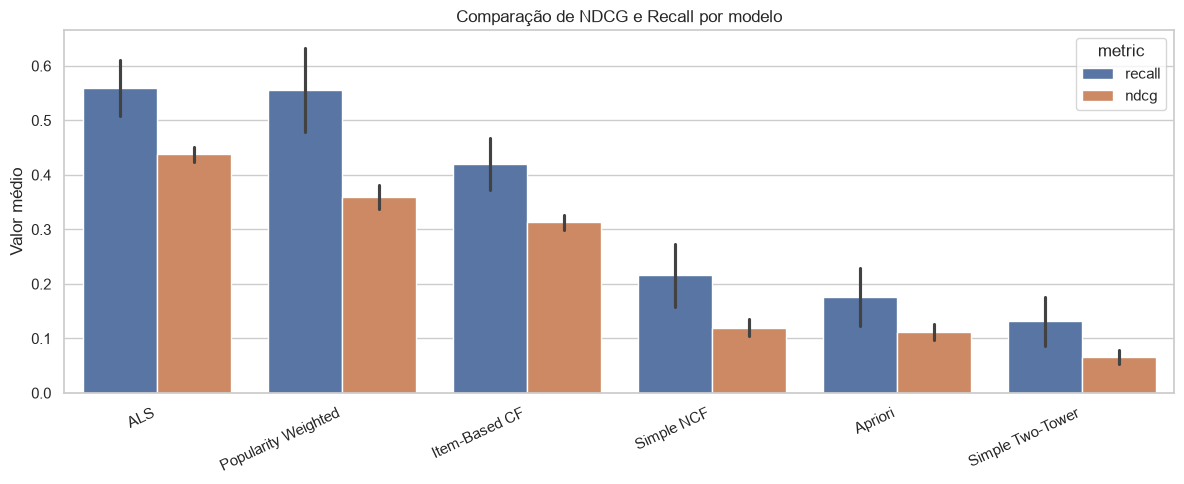

In [53]:
results_long = results_df.melt(
    id_vars=["model", "k"],
    value_vars=["hit_rate", "precision", "recall", "ndcg"],
    var_name="metric",
    value_name="value",
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=results_long[results_long["metric"].isin(["ndcg", "recall"])],
    x="model",
    y="value",
    hue="metric",
)
plt.title("Comparação de NDCG e Recall por modelo")
plt.xlabel("")
plt.ylabel("Valor médio")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


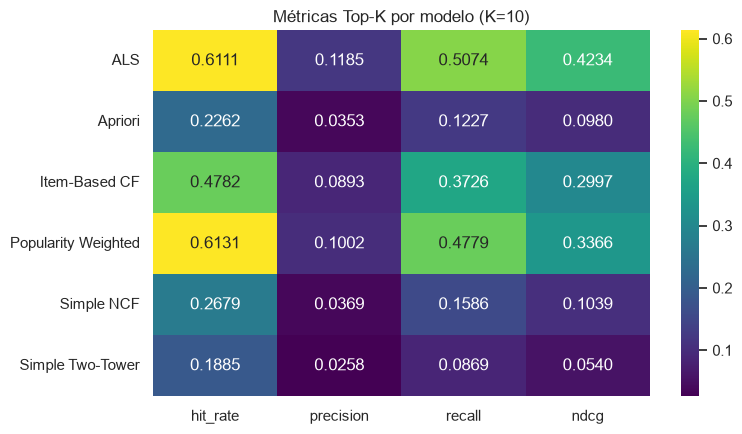

In [54]:
heatmap_data = (
    results_long[results_long["k"] == 10]
    .pivot(index="model", columns="metric", values="value")
    .loc[:, ["hit_rate", "precision", "recall", "ndcg"]]
)

plt.figure(figsize=(8, 4.5))
sns.heatmap(heatmap_data, annot=True, fmt=".4f", cmap="viridis")
plt.title("Métricas Top-K por modelo (K=10)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()


# Conclusões

- A comparação foi organizada como uma escada de complexidade.
- A popularidade ponderada estabelece um baseline global forte e difícil de ignorar.
- O Apriori adiciona regras interpretáveis, mas depende de coocorrências frequentes.
- O Item-Based CF personaliza com base em similaridade entre itens.
- O ALS aprende fatores latentes e costuma capturar padrões menos óbvios.
- O NCF e o Two-Tower trazem uma formulação supervisionada com negative sampling, aproximando a experimentação da lógica final do projeto.

O ponto mais importante é que a comparação agora usa uma base comum, rótulos consistentes e o mesmo conjunto de candidatos por usuário. Assim, diferenças de métrica passam a refletir melhor as escolhas de modelagem, e não diferenças acidentais de preparação dos dados.
